# Forecasting Analysis

This notebook uses `src/forecasting.py` as the single source of truth for the forecasting workflow.

It evaluates short-term forecasts for `daily_revenue` and `daily_order_volume` with Seasonal Naive and Gradient Boosting, then uses the lower-RMSE model for the next 30 days.

The notebook now includes visuals for the historical signal, weekly operating rhythm, model comparison, and the near-term forecast outlook.


## Notebook Setup

The next cell imports the forecasting helpers from `src/forecasting.py`, loads the plotting libraries used for the visuals, and defines the shared colors and axis formatters used throughout the notebook.


In [35]:
"""Import forecasting utilities, exported visuals, and plotting dependencies for the notebook."""

from datetime import date
import importlib
from pathlib import Path
import sys

from IPython import get_ipython
from IPython.display import Image, display
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

root = Path.cwd().resolve()
project_root = root.parent if root.name == "notebooks" else root
src_path = project_root / "src"

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import forecasting

forecasting = importlib.reload(forecasting)

ipython = get_ipython()
if ipython is not None:
    ipython.run_line_magic("matplotlib", "inline")
DATA_PATH = forecasting.DATA_PATH
FORECAST_DAYS = forecasting.FORECAST_DAYS
TEST_DAYS = forecasting.TEST_DAYS
BASELINE_MODEL = forecasting.BASELINE_MODEL
SUPERVISED_MODEL = forecasting.SUPERVISED_MODEL
COMPARISON_MODELS = forecasting.COMPARISON_MODELS
build_visualizations = forecasting.build_visualizations
render_table = forecasting.render_table
run_forecasting_workflow = forecasting.run_forecasting_workflow

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.figsize": (12, 6),
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "bold",
        "axes.labelsize": 11,
    }
)


def format_currency(value, _position):
    return f"${value / 1000:.0f}k"


def format_integer(value, _position):
    return f"{value:.0f}"


TARGET_META = {
    "daily_revenue": {
        "label": "Daily revenue",
        "short_label": "Revenue",
        "color": "#0f766e",
        "unit": "Revenue",
        "axis_formatter": FuncFormatter(format_currency),
    },
    "daily_order_volume": {
        "label": "Daily order volume",
        "short_label": "Orders",
        "color": "#2563eb",
        "unit": "Orders",
        "axis_formatter": FuncFormatter(format_integer),
    },
}

MODEL_COLORS = {
    BASELINE_MODEL: "#1d4ed8",
    SUPERVISED_MODEL: "#dc2626",
}

MODEL_LINESTYLES = {
    BASELINE_MODEL: "--",
    SUPERVISED_MODEL: "-",
}


## Load And Prepare Daily Targets

The cleaned transactional dataset is aggregated into two daily time series:
- `daily_revenue`
- `daily_order_volume`

Missing dates are kept and treated as zero-activity days so the model can learn the weekly operating pattern.

The next cell loads those prepared series and prints the time span, target names, and forecast windows used in the rest of the notebook.


In [36]:
"""Run the shared forecasting workflow and inspect the forecasting window."""

results = run_forecasting_workflow(DATA_PATH)
dates = results["dates"]
targets = results["targets"]
target_names = results["target_names"]
all_metrics = results["metrics"]
all_summaries = results["summaries"]
preview_rows = results["preview_rows"]
comparisons = results["comparisons"]
comparison_lookup = {row["target"]: row for row in comparisons}
metric_lookup = {(row["target"], row["model"]): row for row in all_metrics}
forecast_lookup = {
    target_name: [row for row in results["forecasts"] if row["target"] == target_name]
    for target_name in target_names
}
summary_lookup = {row["target"]: row for row in all_summaries}
preview_lookup = {
    target_name: [row for row in preview_rows if row["target"] == target_name]
    for target_name in target_names
}

print(f"Source rows: {results['source_row_count']} transaction lines")
print(f"Observations: {len(dates)} daily records")
print(f"Date range: {dates[0].isoformat()} to {dates[-1].isoformat()}")
print("Targets:", ", ".join(target_names))
print(f"Holdout window: last {TEST_DAYS} days")
print(f"Forecast horizon: next {FORECAST_DAYS} days")


Source rows: 333234 transaction lines
Observations: 374 daily records
Date range: 2010-12-01 to 2011-12-09
Targets: daily_revenue, daily_order_volume
Holdout window: last 30 days
Forecast horizon: next 30 days


## Historical Signal

These charts show the full daily history, including the raw observations, a 7-day smoothing line, and the recurring zero-activity days that shape the weekly seasonality.

The next cell plots both targets across the full date range so the level shifts, volatility, and repeated zero-activity days are visible at a glance.


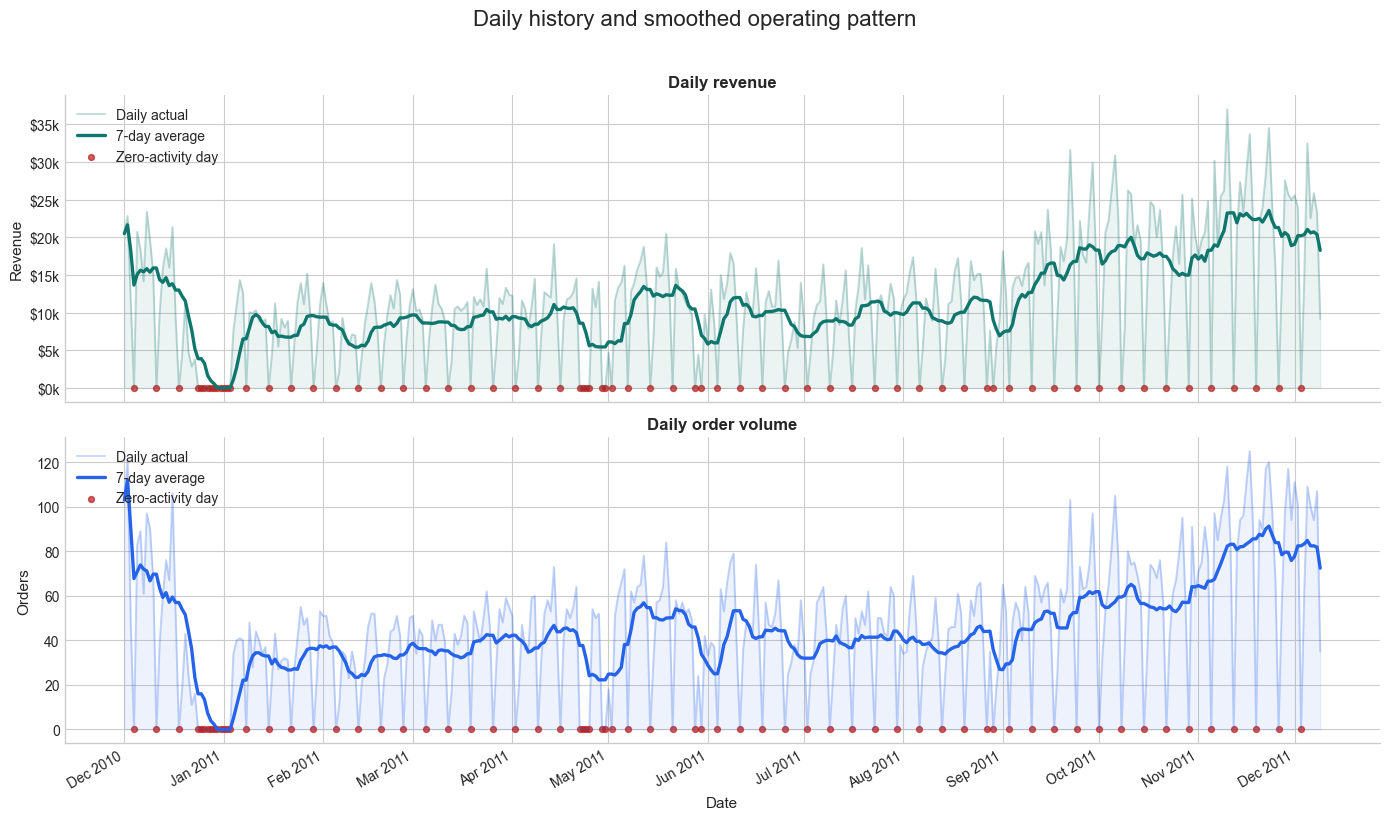

In [37]:
"""Plot the full daily history to highlight volatility, seasonality, and zero-activity days."""

rolling_window = 7


def moving_average(values, window):
    averages = []
    for index in range(len(values)):
        start = max(0, index - window + 1)
        window_values = values[start : index + 1]
        averages.append(sum(window_values) / len(window_values))
    return averages


fig, axes = plt.subplots(len(target_names), 1, figsize=(14, 8), sharex=True)

for axis, target_name in zip(axes, target_names):
    series = targets[target_name]
    meta = TARGET_META[target_name]
    smoothed = moving_average(series, rolling_window)

    axis.plot(dates, series, color=meta["color"], alpha=0.25, linewidth=1.4, label="Daily actual")
    axis.plot(dates, smoothed, color=meta["color"], linewidth=2.4, label=f"{rolling_window}-day average")
    axis.fill_between(dates, series, color=meta["color"], alpha=0.08)

    zero_days = [current_date for current_date, value in zip(dates, series) if value == 0]
    if zero_days:
        axis.scatter(zero_days, [0] * len(zero_days), color="#b91c1c", s=18, alpha=0.7, label="Zero-activity day")

    axis.set_title(meta["label"])
    axis.set_ylabel(meta["unit"])
    axis.yaxis.set_major_formatter(meta["axis_formatter"])
    axis.legend(loc="upper left")

axes[-1].set_xlabel("Date")
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=1))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
fig.suptitle("Daily history and smoothed operating pattern", fontsize=16, y=1.02)
fig.autofmt_xdate()
plt.tight_layout()
display(fig)
plt.close(fig)


## Historical Signal Interpretation

The two series move together closely across the full time range. Both revenue and order volume show the same broad peaks, troughs, and repeated zero-activity days, which means the business is following a consistent weekly operating rhythm rather than changing randomly over time.

Daily revenue is more volatile than daily order volume because it captures both how many orders were placed and how much each order was worth. Order volume is smoother in scale, but its turning points line up with revenue, so the main rises and falls in revenue appear to be driven by demand volume rather than sudden shifts in basket value.

The 7-day moving averages have a very similar shape, with a correlation of about `0.95`. When the moving average for order volume increases, the moving average for revenue increases at nearly the same time, and when one softens the other softens as well. That similarity suggests short-term revenue is strongly linked to order flow, which is useful for forecasting because the same weekly pattern is visible in both targets.


## Weekly Demand Profile

This view condenses the full history into average weekday behavior, which makes the repeating operational rhythm easier to scan than the raw time series alone.

The next cell calculates the average value for each weekday and plots the typical weekly shape for revenue and order volume.


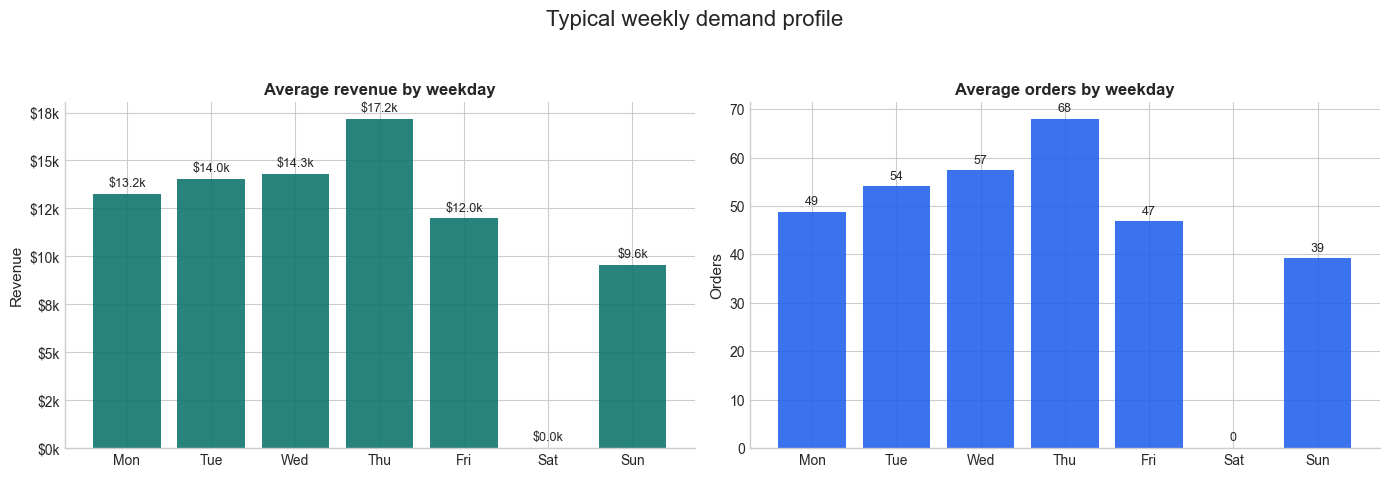

In [38]:
"""Summarize the average weekly operating profile for revenue and order volume."""

weekday_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

fig, axes = plt.subplots(1, len(target_names), figsize=(14, 4.5), sharey=False)

for axis, target_name in zip(axes, target_names):
    meta = TARGET_META[target_name]
    weekday_groups = {index: [] for index in range(7)}

    for current_date, value in zip(dates, targets[target_name]):
        weekday_groups[current_date.weekday()].append(value)

    weekday_averages = [
        sum(weekday_groups[index]) / len(weekday_groups[index])
        for index in range(7)
    ]

    bars = axis.bar(weekday_names, weekday_averages, color=meta["color"], alpha=0.9)
    axis.bar_label(
        bars,
        labels=[
            f"${value / 1000:.1f}k" if target_name == "daily_revenue" else f"{value:.0f}"
            for value in weekday_averages
        ],
        padding=3,
        fontsize=9,
    )
    axis.set_title(f"Average {meta['short_label'].lower()} by weekday")
    axis.set_ylabel(meta["unit"])
    axis.yaxis.set_major_formatter(meta["axis_formatter"])
    axis.set_ylim(bottom=0)

fig.suptitle("Typical weekly demand profile", fontsize=16, y=1.05)
plt.tight_layout()
display(fig)
plt.close(fig)


## Weekly Demand Profile Interpretation

Revenue and order volume follow the same weekday rhythm. Both series peak on `Thursday`, with average daily revenue around `$17.2k` and average order volume around `68` orders, and both drop to `0` on `Saturday`, which indicates the business is operating on a stable weekly schedule.

Revenue swings more sharply than order volume because it reflects both the number of orders and the value of those orders. Even so, the matching weekday highs and lows suggest the weekly revenue pattern is driven mainly by order flow rather than a completely different pricing or basket-size pattern.


## Evaluate Competing Forecast Models

Each target is split chronologically:
- training set: all observations except the final 30 days
- test set: the final 30 days

The notebook scores two approaches with MAE, RMSE, and WAPE:
- `Seasonal Naive` as the baseline
- `Gradient Boosting` as the feature-based approach built from richer transaction-derived daily signals

`Accuracy` is not used here because both targets are continuous regression outputs rather than class labels.

The next cell prints the full holdout metric table used for model selection, and the visuals after that compare both models on the same axes.


In [39]:
"""Display the model evaluation returned by the shared forecasting workflow."""

print("Model evaluation:")
print(render_table(all_metrics, ["target", "model", "mae", "rmse", "wape"]))


Model evaluation:
target              model              mae      rmse     wape 
------------------  -----------------  -------  -------  -----
daily_revenue       Seasonal Naive     5822.61  8048.46  27.42
daily_revenue       Gradient Boosting  4348.53  5986.90  20.48
daily_order_volume  Seasonal Naive     14.70    19.06    17.84
daily_order_volume  Gradient Boosting  16.73    20.53    20.30


### Saved Benchmark Note

The printed metrics above are the last saved notebook outputs. Because `src/forecasting.py` now uses a richer transaction-derived feature set, rerun the evaluation cells before quoting updated `MAE`, `RMSE`, or `WAPE` values in the report or presentation.


## Model Comparison Visual

The grouped charts below compare `Seasonal Naive` and `Gradient Boosting` side by side. That view makes it easier to see whether the richer customer, basket-value, product-mix, and calendar signals add value beyond the weekly seasonal baseline.


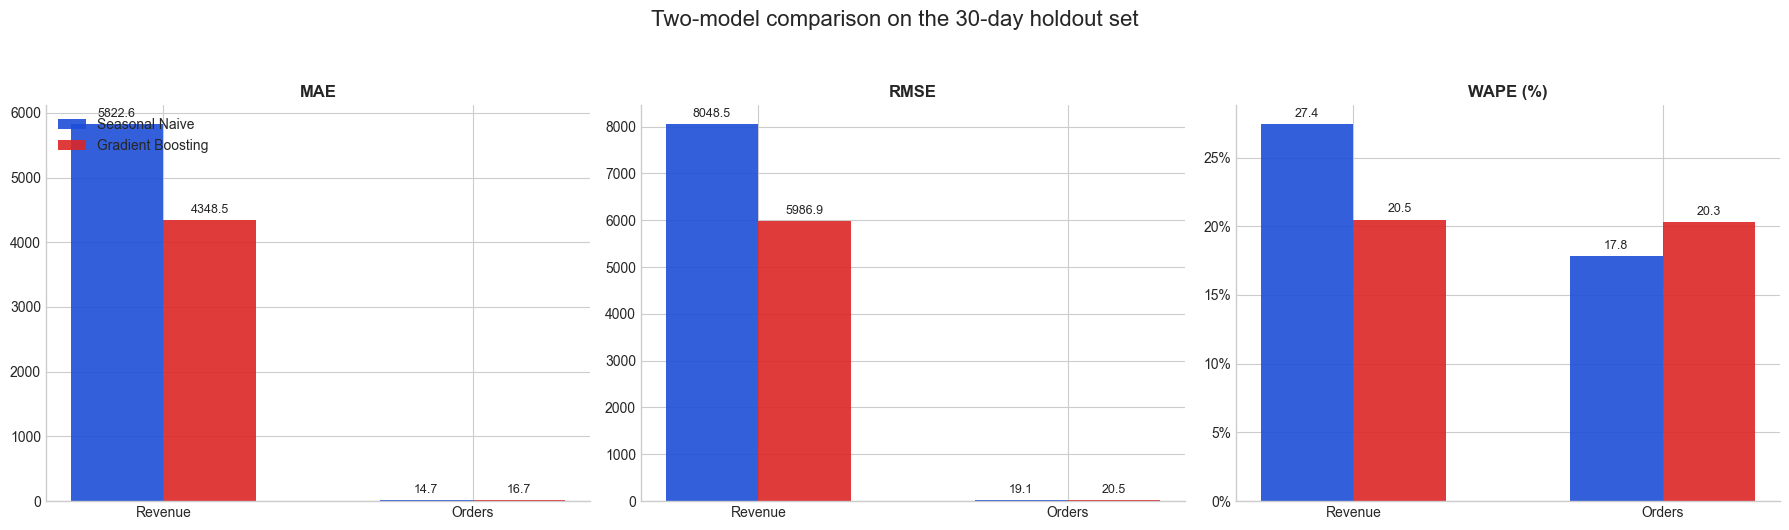

In [40]:
"""Visualize the holdout-set metrics for the remaining candidate models."""

metric_names = ["mae", "rmse", "wape"]
metric_titles = {"mae": "MAE", "rmse": "RMSE", "wape": "WAPE (%)"}
target_positions = list(range(len(target_names)))
bar_width = 0.3

fig, axes = plt.subplots(1, len(metric_names), figsize=(18, 5), sharey=False)

for axis, metric_name in zip(axes, metric_names):
    for offset, model_name in enumerate(COMPARISON_MODELS):
        model_values = []
        for target_name in target_names:
            metric_row = metric_lookup[(target_name, model_name)]
            model_values.append(metric_row[metric_name])

        bar_positions = [
            position + (offset - (len(COMPARISON_MODELS) - 1) / 2) * bar_width
            for position in target_positions
        ]
        bars = axis.bar(
            bar_positions,
            model_values,
            width=bar_width,
            color=MODEL_COLORS[model_name],
            alpha=0.9,
            label=model_name,
        )
        axis.bar_label(bars, fmt="%.1f", padding=3, fontsize=9)

    axis.set_title(metric_titles[metric_name])
    axis.set_xticks(target_positions, [TARGET_META[name]["short_label"] for name in target_names])
    if metric_name == "wape":
        axis.yaxis.set_major_formatter(FuncFormatter(lambda value, _position: f"{value:.0f}%"))

axes[0].legend(loc="upper left")
fig.suptitle("Two-model comparison on the 30-day holdout set", fontsize=16, y=1.05)
plt.tight_layout()
display(fig)
plt.close(fig)


## Model Comparison Interpretation

The holdout comparison now focuses on the practical choice between `Seasonal Naive` and `Gradient Boosting`.

After the feature upgrade, the main expectation is that `Gradient Boosting` should be strongest when the target depends on richer daily demand context such as customer mix, order size, product concentration, and geography. `Seasonal Naive` can still remain competitive for targets whose behavior is dominated by a stable weekly rhythm. The forecast step therefore continues to select the lowest-RMSE model separately for each target.


## Forecast Summary

The forward forecast still selects the lowest-RMSE model per target. Because the supervised feature set was expanded in `src/forecasting.py`, rerun the notebook before describing the current winner for each target.

The next cell prints the selected-model forecast totals and a short preview of the first 7 forecasted days for both targets.


In [41]:
"""Display the 30-day summary and next-week preview from the shared workflow."""

print("30-day forecast summary:")
print(
    render_table(
        all_summaries,
        [
            "target",
            "selected_model",
            "30_day_total_forecast",
            "average_daily_forecast",
            "peak_day_forecast",
        ],
    )
)

print()
print("Next 7 forecasted days:")
print(render_table(preview_rows, ["date", "target", "model", "forecast"]))


30-day forecast summary:
target              selected_model     30_day_total_forecast  average_daily_forecast  peak_day_forecast
------------------  -----------------  ---------------------  ----------------------  -----------------
daily_revenue       Gradient Boosting  540563.44              18018.78                28758.04         
daily_order_volume  Seasonal Naive     2090.00                69.67                   109.00           

Next 7 forecasted days:
date        target              model              forecast
----------  ------------------  -----------------  --------
2011-12-10  daily_revenue       Gradient Boosting  0.00    
2011-12-11  daily_revenue       Gradient Boosting  12247.45
2011-12-12  daily_revenue       Gradient Boosting  21999.11
2011-12-13  daily_revenue       Gradient Boosting  24171.27
2011-12-14  daily_revenue       Gradient Boosting  24450.05
2011-12-15  daily_revenue       Gradient Boosting  22790.28
2011-12-16  daily_revenue       Gradient Boosting  175

## Forecast Outlook Visual

These charts place the most recent 60 days of actual observations next to the next 30 forecasted days and overlay the two remaining candidate models. That makes it easy to compare the repeated weekly baseline against the feature-based forecast.

The dotted divider marks the point where the forecast begins, and the shaded area shows the forward horizon.


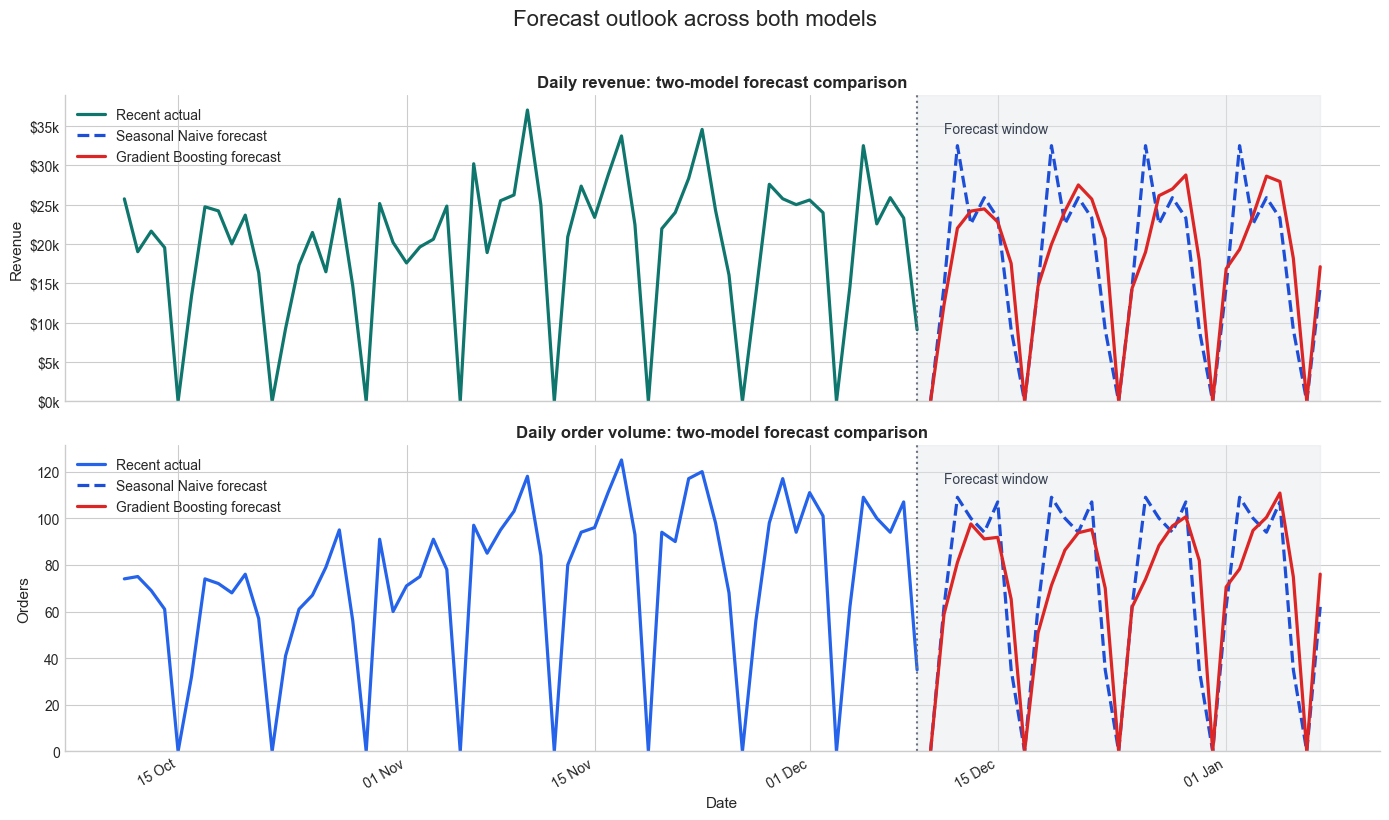

In [42]:
"""Plot recent history against both candidate forecasts."""

history_window = 60
fig, axes = plt.subplots(len(target_names), 1, figsize=(14, 8), sharex=False)

for axis, target_name in zip(axes, target_names):
    meta = TARGET_META[target_name]
    history_dates = dates[-history_window:]
    history_values = targets[target_name][-history_window:]
    comparison = comparison_lookup[target_name]
    future_dates = comparison["future_dates"]

    axis.plot(history_dates, history_values, color=meta["color"], linewidth=2.3, label="Recent actual")
    for model_name in COMPARISON_MODELS:
        axis.plot(
            future_dates,
            comparison["future_predictions"][model_name],
            color=MODEL_COLORS[model_name],
            linewidth=2.3,
            linestyle=MODEL_LINESTYLES[model_name],
            label=f"{model_name} forecast",
        )

    axis.axvline(dates[-1], color="#6b7280", linestyle=":", linewidth=1.5)
    axis.axvspan(dates[-1], future_dates[-1], color="#e5e7eb", alpha=0.45)
    axis.text(
        future_dates[1],
        max(
            max(history_values),
            *(max(comparison["future_predictions"][model_name]) for model_name in COMPARISON_MODELS),
        ) * 0.92,
        "Forecast window",
        color="#374151",
        fontsize=10,
    )

    axis.set_title(f"{meta['label']}: two-model forecast comparison")
    axis.set_ylabel(meta["unit"])
    axis.set_ylim(bottom=0)
    axis.yaxis.set_major_formatter(meta["axis_formatter"])
    axis.legend(loc="upper left")
    axis.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=6, maxticks=10))
    axis.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))

axes[-1].set_xlabel("Date")
fig.suptitle("Forecast outlook across both models", fontsize=16, y=1.02)
fig.autofmt_xdate()
plt.tight_layout()
display(fig)
plt.close(fig)


## Forecast Outlook Interpretation

For `daily_revenue`, the main question is whether `Gradient Boosting` adds enough signal beyond the weekly seasonal repeat, and the visual is intended to show whether the richer transaction-derived features let it follow recent demand changes without simply copying the last observed week.

For `daily_order_volume`, the notebook still compares the feature-based forecast directly against `Seasonal Naive`, which keeps the interpretation aligned with the reduced two-model workflow used in `forecasting.py`.


## Forecasted Trends

The short narrative below is generated from the computed forecast tables so the explanation stays in sync with the model output.

The next cell converts the selected forecast outputs into a short operational summary that can be reused in the report or presentation.


In [43]:
"""Turn the selected forecasts into a short operational narrative."""

revenue_summary = summary_lookup["daily_revenue"]
volume_summary = summary_lookup["daily_order_volume"]
revenue_preview = preview_lookup["daily_revenue"]
volume_preview = preview_lookup["daily_order_volume"]

zero_revenue_days = [row["date"] for row in revenue_preview if row["forecast"] == 0]
peak_revenue_day = max(revenue_preview, key=lambda row: row["forecast"])
peak_volume_day = max(volume_preview, key=lambda row: row["forecast"])

print("Forecasted trends:")
print(
    f"- Revenue uses {revenue_summary['selected_model']} and is projected at {revenue_summary['30_day_total_forecast']:.2f} over the next 30 days, averaging {revenue_summary['average_daily_forecast']:.2f} per day."
)
print(
    f"- Order volume uses {volume_summary['selected_model']} and is projected at {volume_summary['30_day_total_forecast']:.0f} orders over the next 30 days, averaging {volume_summary['average_daily_forecast']:.2f} orders per day."
)
print(
    f"- The next week includes zero-revenue days on {', '.join(zero_revenue_days)} and peaks on {peak_revenue_day['date']} for revenue ({peak_revenue_day['forecast']:.2f}) and {peak_volume_day['date']} for order volume ({peak_volume_day['forecast']:.0f})."
)


Forecasted trends:
- Revenue uses Gradient Boosting and is projected at 540563.44 over the next 30 days, averaging 18018.78 per day.
- Order volume uses Seasonal Naive and is projected at 2090 orders over the next 30 days, averaging 69.67 orders per day.
- The next week includes zero-revenue days on 2011-12-10 and peaks on 2011-12-14 for revenue (24450.05) and 2011-12-12 for order volume (109).


## Exported Visual Assets

The notebook also shows the PNGs exported by `src/forecasting.py`. These are useful for dropping directly into the report or presentation without rerunning the plotting code elsewhere, and they compare the two candidate models plus the selected 30-day outlook.


model_metric_comparison.png


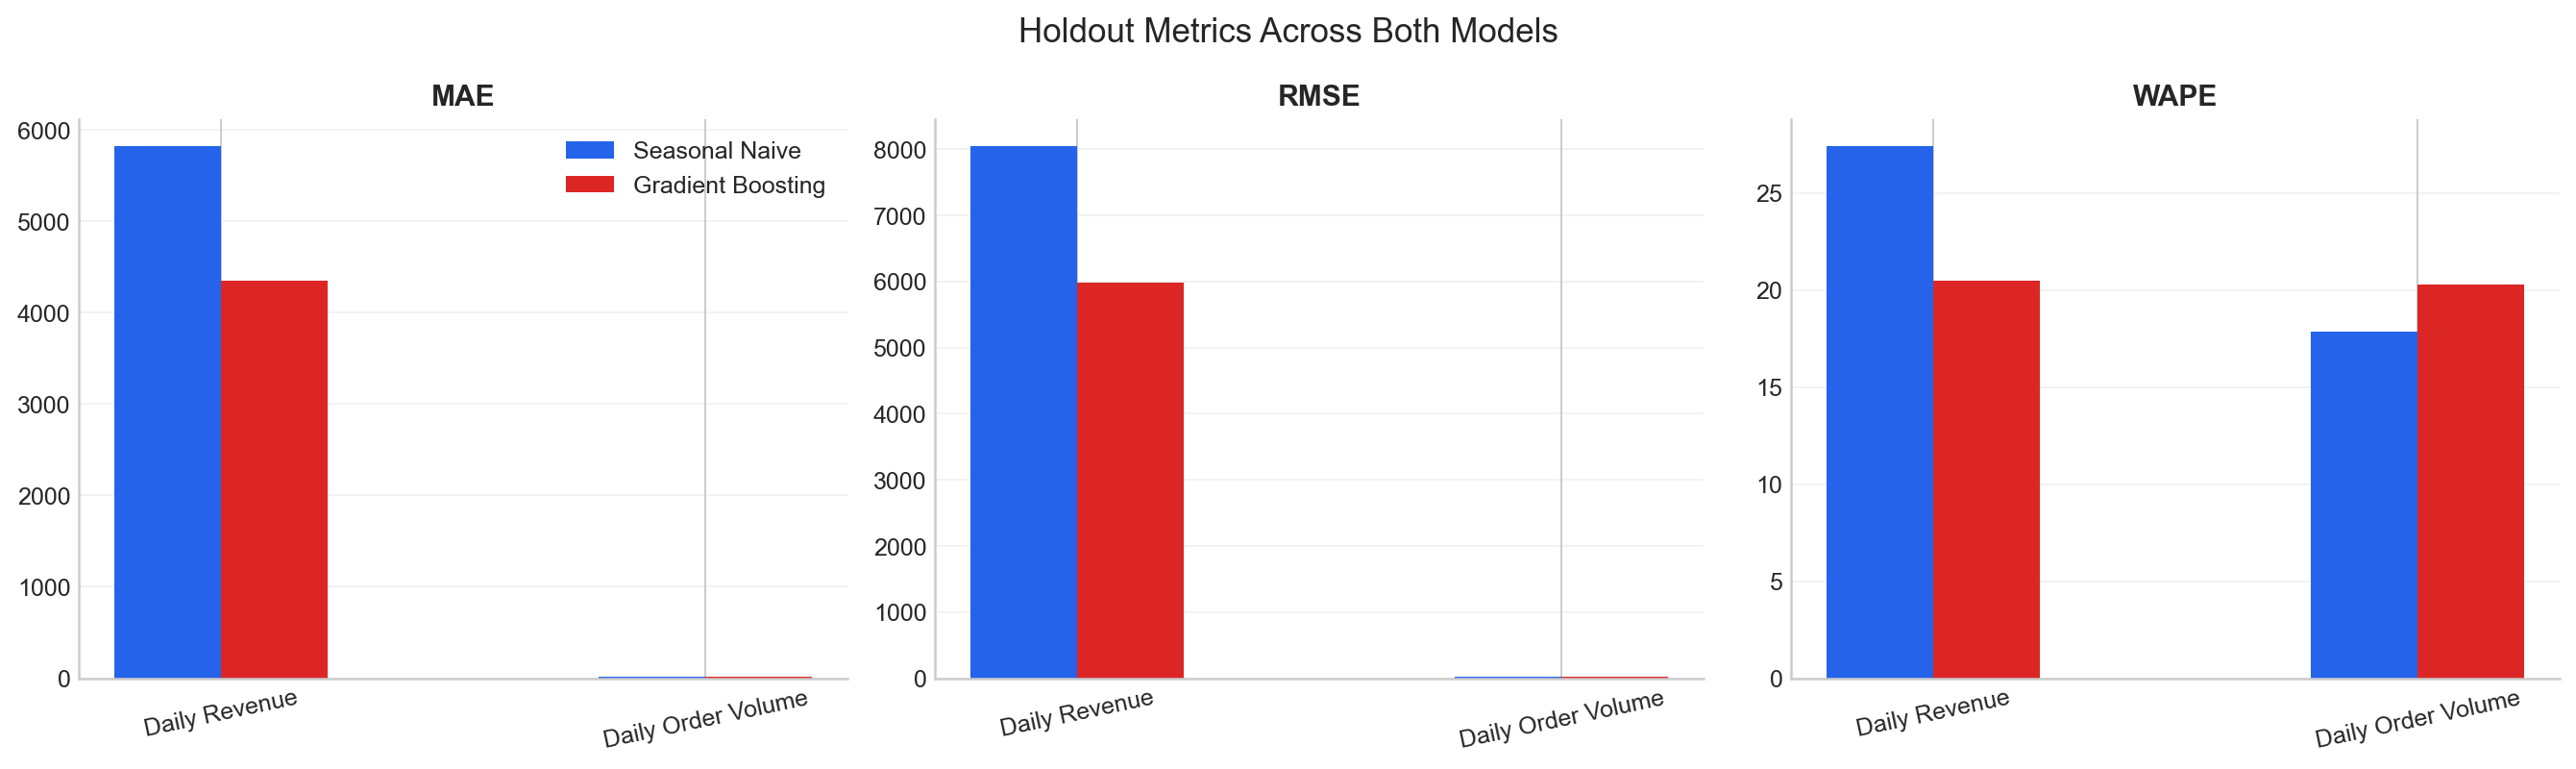


holdout_comparison.png


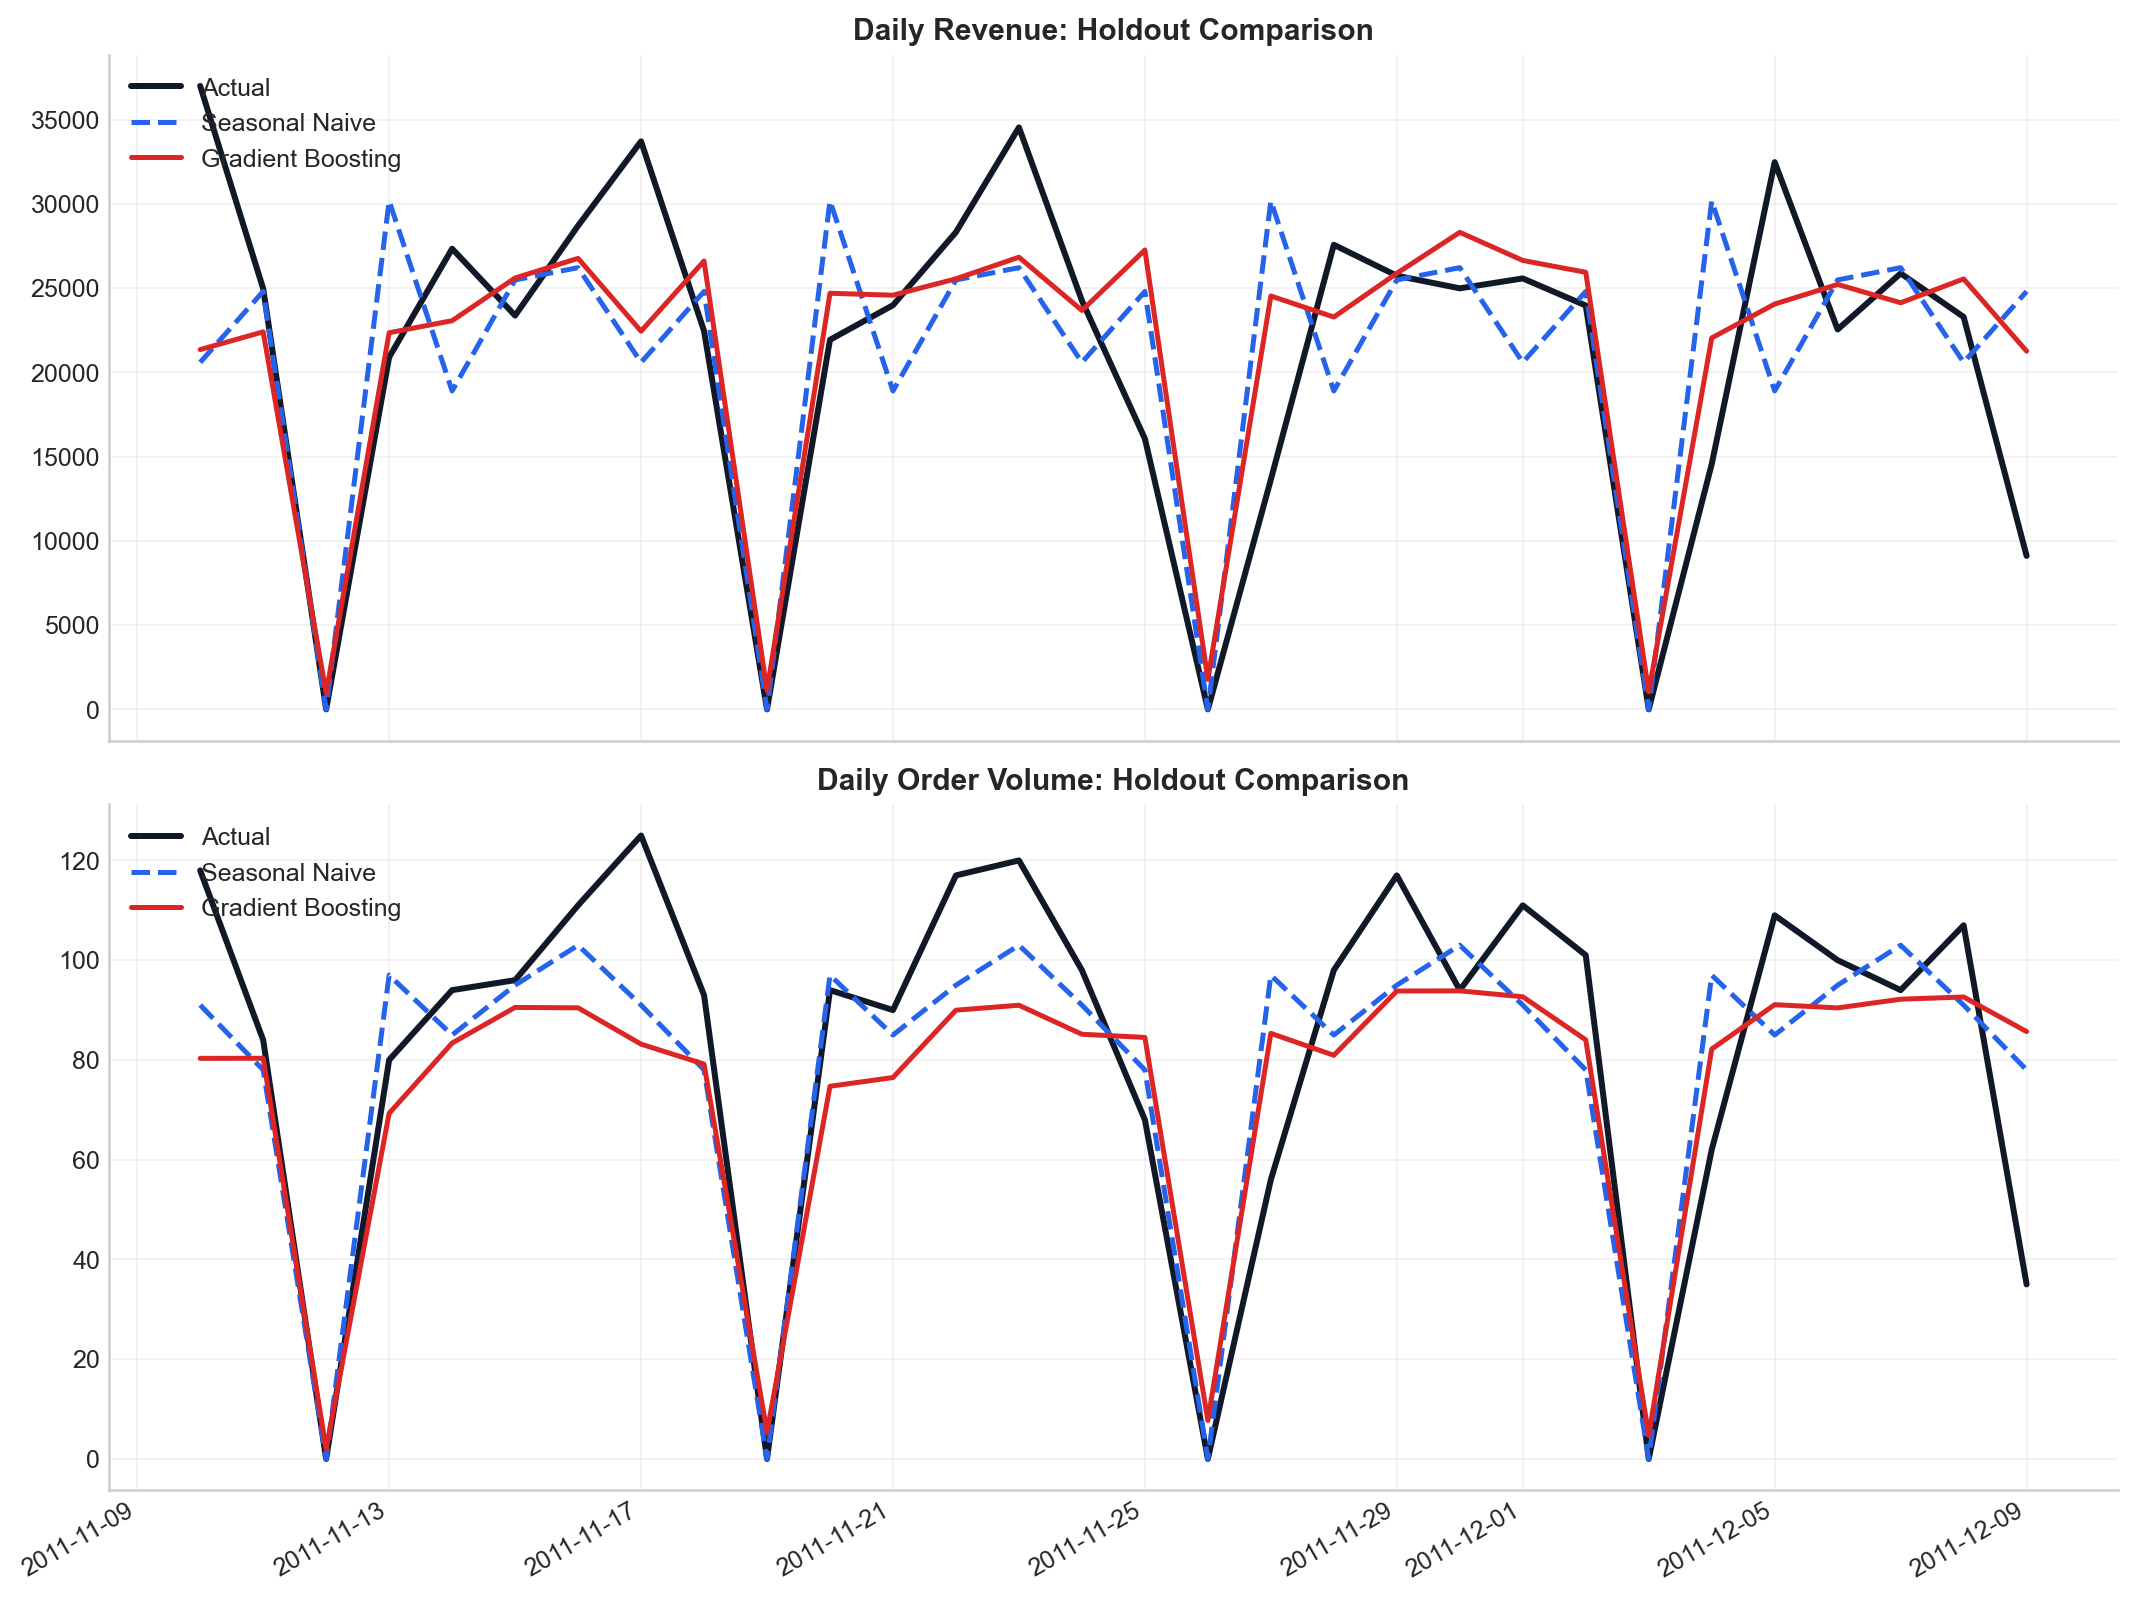


future_forecast_comparison.png


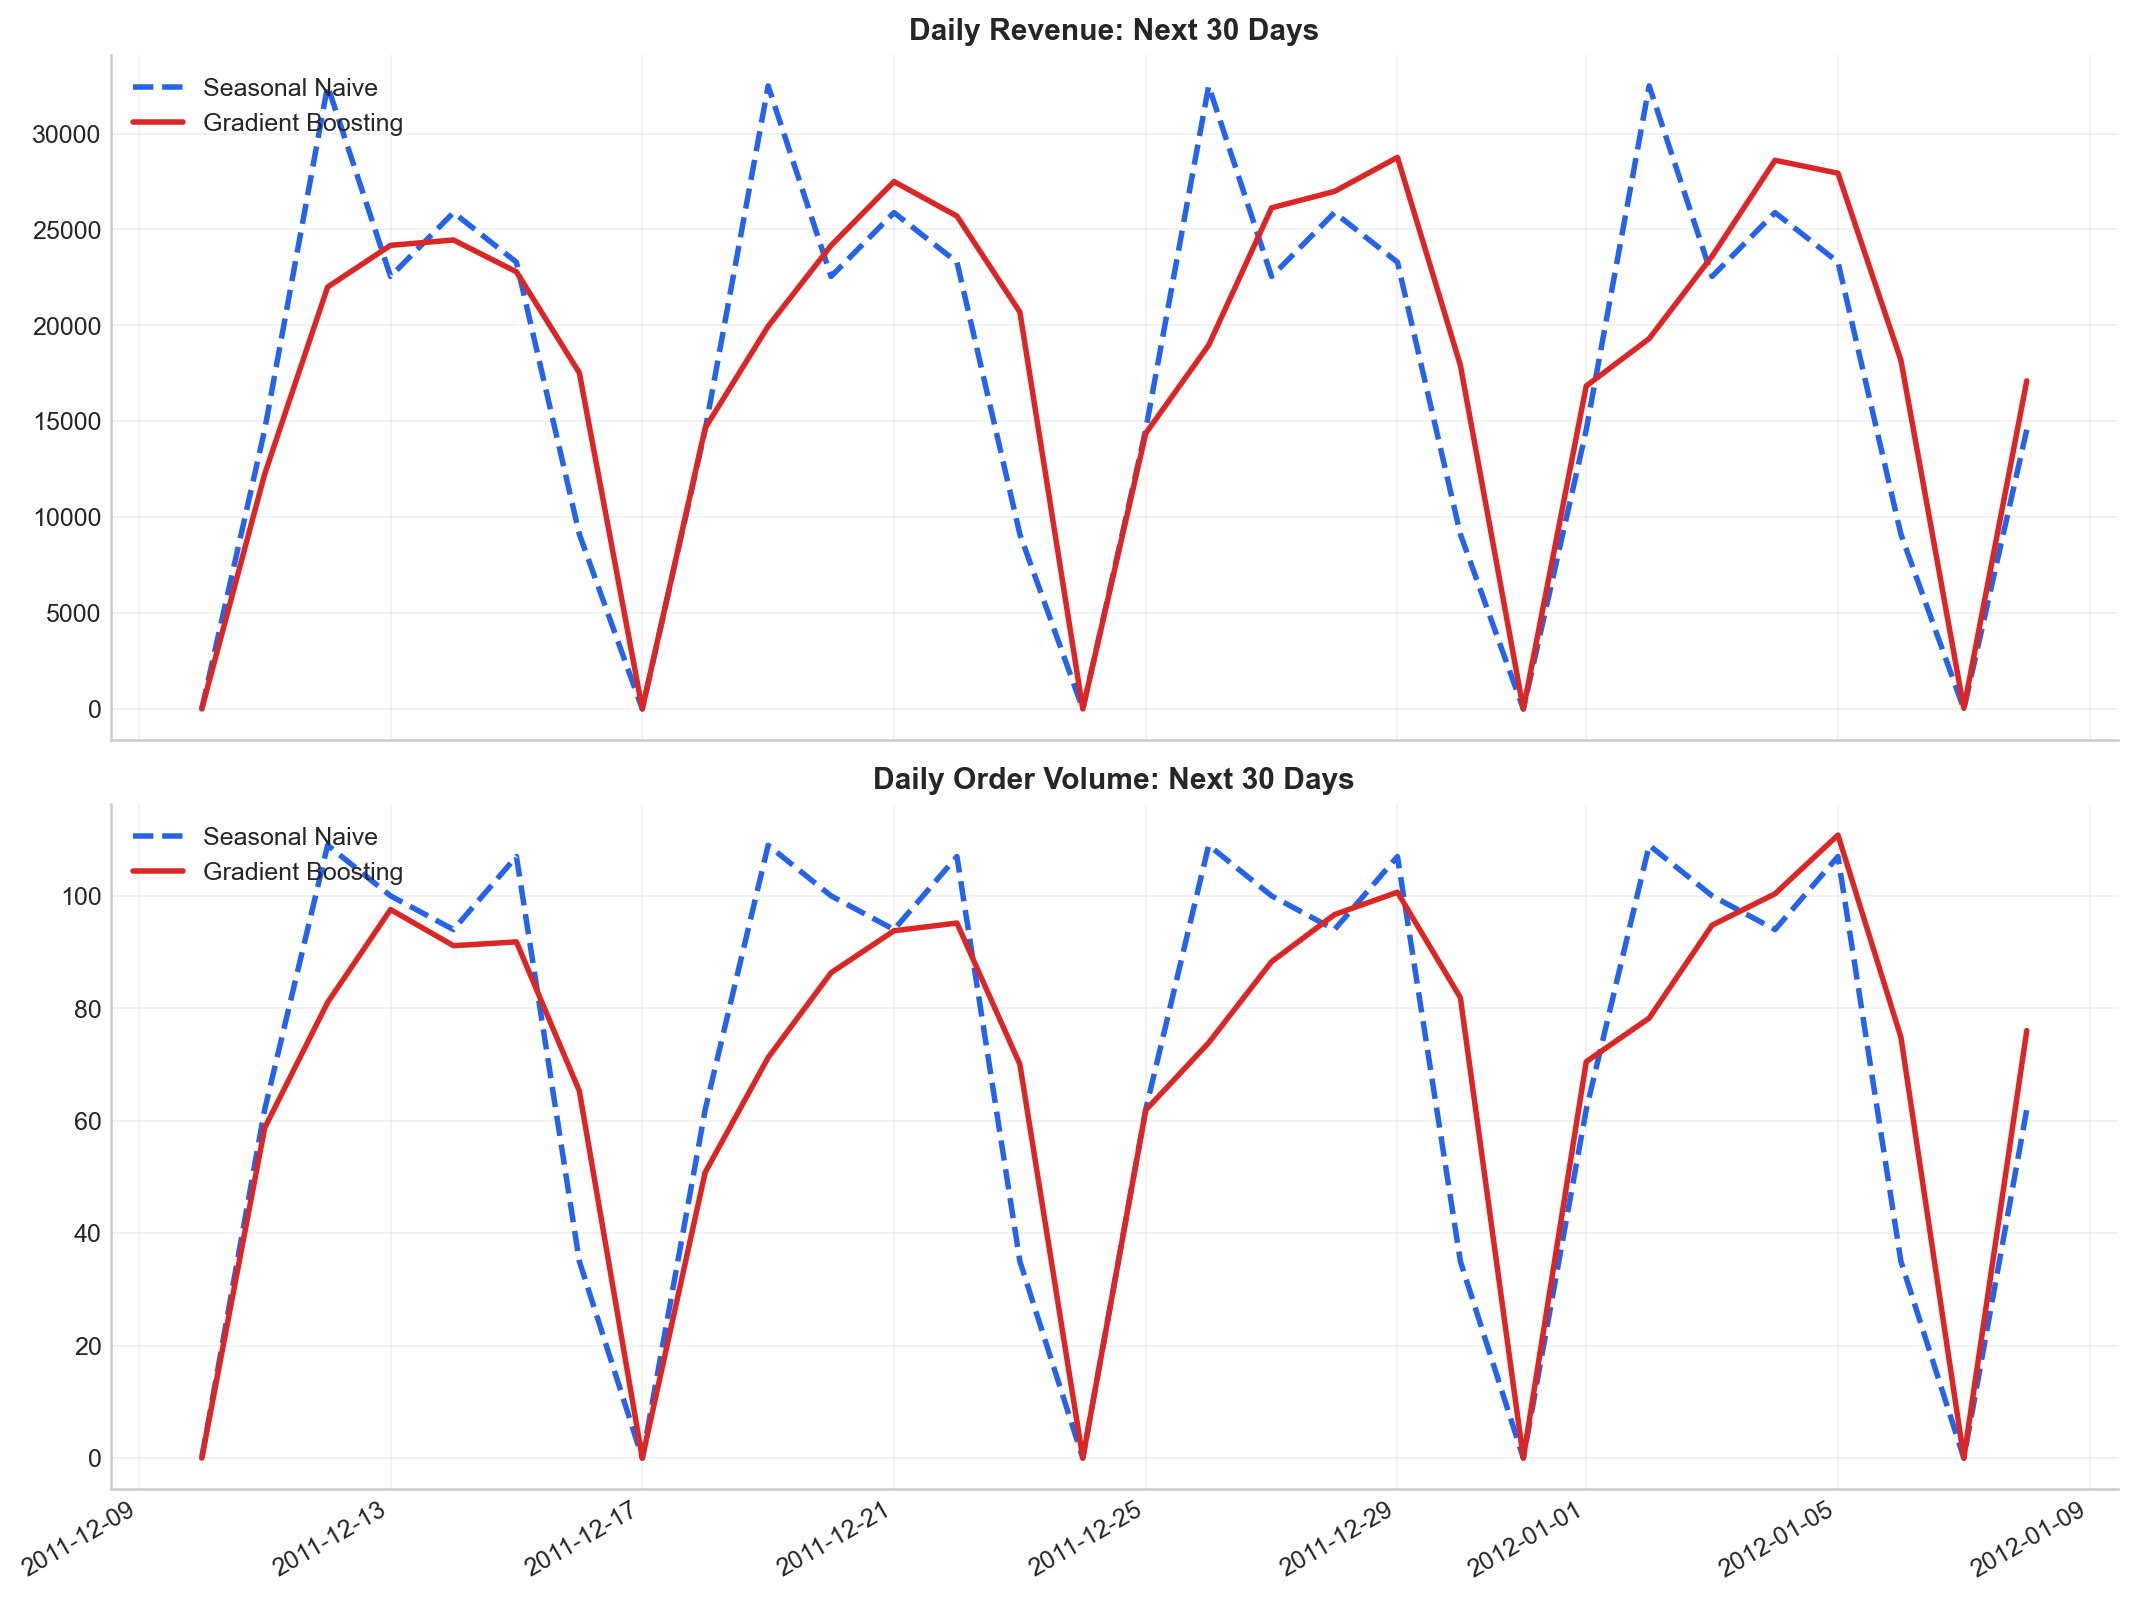

In [44]:
"""Display the exported forecasting visuals saved by the shared script."""

visual_paths = build_visualizations(results)
for visual_path in visual_paths:
    print(visual_path.name)
    display(Image(filename=str(visual_path)))
    print()


## Operational Impact

Short-term forecasts from this notebook can be used to:
- plan staffing for order-processing peaks
- prepare replenishment for higher-demand days
- estimate near-term revenue for tactical cash-flow decisions

The main limitation is that the model still works at the daily aggregation level. It now uses richer customer, basket-value, product-mix, geography, and intraday summary features than the original baseline, but promotions, holidays, and supply disruptions are still excluded, so the forecasts should be used as tactical guidance rather than a long-range plan.
